In [1]:
import glob
import json
import random
import re
from os.path import join as opj

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.models.model_predictions import woven_stiff_pred
from cloth_fmri.utils.rdm import (
    build_model_rdm_from_stiffness_predictions,
    build_rdm,
)
from cloth_fmri.utils.stats import bootstrap_cor, get_mode_value

random.seed(9)

C_VALUES = ["0.1", "1.0", "10.0", "100.0"]
SUBJECT_LIST = CONFIG["subjects"]
SCENES = CONFIG["scenes"]
# The Physics ROI is stored under "tower" in the existing analysis outputs.
HUMAN_RDM_ROOT = opj(CONFIG["output_root"], "analysis", "fig4", "tower")
VIDEO_MODEL_DIRS = {
    "vjepa2": "vjepa2_hf_ridge_mean_1.0_ntrain=7075",
    "videomae": "videomae_ridge_mean_1.0_ntrain=7075",
    "vivit": "vivit_ridge_cls_1.0_ntrain=7075",
}
LABELS = {"vjepa2": "V-JEPA2", "videomae": "VideoMAE", "vivit": "ViViT"}



In [2]:
# Select the Physics ROI RDMs using the original split-half reliability criterion.
best_split_half_cor = -1.0
best_subject_rdms = None
best_c = None

for c in C_VALUES:
    matching_files = glob.glob(opj(HUMAN_RDM_ROOT, f"C={c}", "*.json*"))
    if not matching_files:
        continue

    all_data = None
    for file in matching_files:
        with open(file, "r") as f:
            data = json.load(f)
        if all_data is None:
            all_data = {
                sub: {scene: [value] for scene, value in scenes.items()}
                for sub, scenes in data.items()
            }
        else:
            for sub, scenes in all_data.items():
                for scene, values in scenes.items():
                    values.append(data[sub][scene])

    all_data_mean = {
        sub: {scene: get_mode_value(values) for scene, values in scenes.items()}
        for sub, scenes in all_data.items()
    }
    subject_rdms = {
        sub: build_rdm(all_data_mean[sub], SCENES, plot=False)
        for sub in SUBJECT_LIST
        if sub in all_data_mean
    }
    if not subject_rdms:
        continue

    split_half_cor, _, _ = bootstrap_cor(
        np.array(list(subject_rdms.values())), seed=0
    )
    if split_half_cor >= best_split_half_cor:
        best_split_half_cor = split_half_cor
        best_subject_rdms = subject_rdms
        best_c = c

if best_subject_rdms is None:
    raise RuntimeError(f"No valid Physics ROI RDMs found under {HUMAN_RDM_ROOT}")

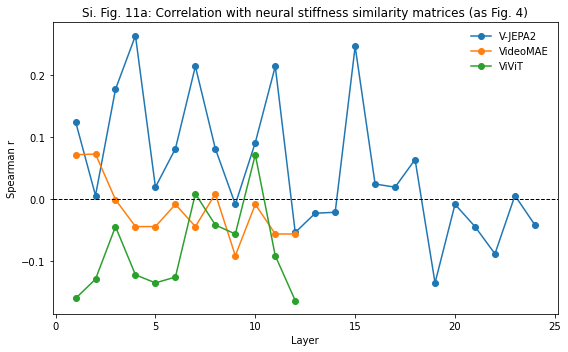

In [3]:
woven_rdm, _ = build_model_rdm_from_stiffness_predictions(woven_stiff_pred, SCENES)
all_layer_results = []

# Correlate each layer's model RDM with each subject's Physics ROI RDM,
# then average the subject-level Spearman correlations (as in the original).
fig, ax = plt.subplots(figsize=(8, 5))
plotted_models = 0

for model, model_dir in VIDEO_MODEL_DIRS.items():
    pred_dir = opj(
        CONFIG["output_root"], "analysis", "model_predictions_all_layers", model_dir
    )
    pred_files = sorted(
        glob.glob(opj(pred_dir, "pred_dict_layer_index=*_layer_number=*.npy")),
        key=lambda path: int(re.search(r"layer_index=(\d+)", path).group(1)),
    )
    if not pred_files:
        print(f"No layer prediction files found for {model}")
        continue

    layer_results = []
    for path in pred_files:
        layer_number = int(re.search(r"layer_number=(\d+)", path).group(1))
        layer_pred_dict = np.load(path, allow_pickle=True).item()
        layer_rdm, _ = build_model_rdm_from_stiffness_predictions(
            layer_pred_dict, SCENES
        )
        subject_correlations = [
            spearmanr(layer_rdm, subject_rdm)[0]
            for subject_rdm in best_subject_rdms.values()
        ]
        mean_r = np.mean(subject_correlations)
        woven_r = spearmanr(layer_rdm, woven_rdm)[0]
        all_layer_results.append({
            "model": model,
            "layer_number": layer_number,
            "woven_spearman": woven_r,
            "tower_neural_spearman": mean_r,
        })
        layer_results.append((layer_number, mean_r))

    layer_results.sort(key=lambda result: result[0])
    layers, correlations = zip(*layer_results)
    ax.plot(layers, correlations, marker="o", label=LABELS[model])
    plotted_models += 1

if not plotted_models:
    plt.close(fig)
    raise RuntimeError("No video-model layer prediction files found.")

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Layer")
ax.set_ylabel("Spearman r")
ax.set_title("Si. Fig. 11a: Correlation with neural stiffness similarity matrices (as Fig. 4)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

V-JEPA2: Pearson r = 0.934, p = 2.793e-11, n_layers = 24
VideoMAE: Pearson r = 0.740, p = 0.005908, n_layers = 12
ViViT: Pearson r = 0.854, p = 0.0004055, n_layers = 12
Aggregated: r = 0.908, p = 4.772e-19, n_layers = 48


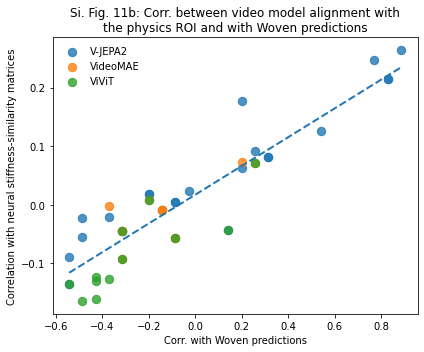

In [4]:
# Combined scatter plot: each point is one layer from one video model.
# Both axes contain RDM Spearman correlations; their association is Pearson.
valid_results = [
    row for row in all_layer_results
    if np.isfinite(row["woven_spearman"])
    and np.isfinite(row["tower_neural_spearman"])
]

if not valid_results:
    raise RuntimeError("No finite Woven/Physics ROI correlations available to plot.")

x = np.array([row["woven_spearman"] for row in valid_results])
y = np.array([row["tower_neural_spearman"] for row in valid_results])

fig, ax = plt.subplots(figsize=(6, 5))

# Scatter points and print Pearson correlation for each video model.
for model in VIDEO_MODEL_DIRS:
    rows = [row for row in valid_results if row["model"] == model]
    if not rows:
        continue

    model_x = np.array([row["woven_spearman"] for row in rows])
    model_y = np.array([row["tower_neural_spearman"] for row in rows])
    ax.scatter(model_x, model_y, s=70, alpha=0.8, label=LABELS[model])

    model_r, model_p = pearsonr(model_x, model_y)
    print(f"{LABELS[model]}: Pearson r = {model_r:.3f}, "
          f"p = {model_p:.4g}, n_layers = {len(model_x)}")


# Overall correlation and one pooled regression line.
r, p = pearsonr(x, y)
print(
    f"Aggregated: r = {r:.3f}, "
    f"p = {p:.4g}, n_layers = {len(x)}"
)

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linestyle="--",
    linewidth=2,
)

corr_text = (
    rf"$r$ = {r:.2f}, $p$ < .001"
    if p < 0.001
    else rf"$r$ = {r:.2f}, $p$ = {p:.3f}"
)


ax.set_xlabel("Corr. with Woven predictions")
ax.set_ylabel("Correlation with neural stiffness-similarity matrices")
ax.set_title(
    "Si. Fig. 11b: Corr. between video model alignment with\n"
    "the physics ROI and with Woven predictions"
)

ax.legend(frameon=False)
fig.tight_layout()

plt.show()